In [1]:
from astropy.io import fits
from astropy.wcs import WCS
import astropy.units as u
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
from astropy.io import fits
from astropy.visualization import simple_norm
from spectral_cube import SpectralCube as sc
from tqdm import trange

from pybaselines import Baseline
from pybaselines.utils import gaussian, relative_difference
from pybaselines._banded_utils import PenalizedSystem
from pybaselines._weighting import _arpls

from joblib import Parallel, delayed
from functools import partial

from pybaselines.utils import ParameterWarning
import warnings

# 屏蔽所有 ParameterWarning
warnings.filterwarnings("ignore")

%matplotlib widget

In [2]:
# Define RA ranges and signs
pattern = "./South/Combined/CRAFTS_RA{ra}_DEC-13_2.fits"
ra_ranges = ["60_80", "80_100", "100_120", "120_140"]
ra_i = 0  # Change this index to select different RA ranges
ra = ra_ranges[ra_i]

# Original file
file = pattern.format(ra=ra)

# Baseline corrected file
corrected_path = "./South/Baseline Corrected/"
corrected_name = f"CRAFTS_RA{ra}_DEC-13_2"

corrected_file_minus = f"{corrected_path}{corrected_name}_cor_-.fits"
corrected_file_plus = f"{corrected_path}{corrected_name}_cor_+.fits"

print(f"Original file: {file}")
print(f"Minus corrected file: {corrected_file_minus}")
print(f"Plus corrected file: {corrected_file_plus}")

Original file: ./South/Combined/CRAFTS_RA60_80_DEC-13_2.fits
Minus corrected file: ./South/Baseline Corrected/CRAFTS_RA60_80_DEC-13_2_cor_-.fits
Plus corrected file: ./South/Baseline Corrected/CRAFTS_RA60_80_DEC-13_2_cor_+.fits


In [3]:
cube = sc.read(file).with_spectral_unit(u.km / u.s)

data = cube.unmasked_data[:, :, :].value
data[np.isnan(data)] = 0

n_v = data.shape[0]
n_y = data.shape[1]
n_x = data.shape[2]

velocities = cube.spectral_axis.value
cube

SpectralCube with shape=(5962, 600, 800) and unit=K:
 n_x:    800  type_x: RA---CAR  unit_x: deg    range:    60.012500 deg:   79.987500 deg
 n_y:    600  type_y: DEC--CAR  unit_y: deg    range:   -12.987500 deg:    1.987500 deg
 n_s:   5962  type_s: VRAD      unit_s: km / s  range:     -599.897 km / s:     599.954 km / s

In [4]:
def masked_arpls(y, mask=None, lam=1e8, diff_order=2, tol=1e-3, max_iter=50, weights=None):
    """A mask-aware version of the arpls algorithm."""
    len_y = len(y)
    if mask is None:
        mask = np.ones(len_y, dtype=bool)
        y_fit = y
    else:
        y_fit = 1 * y  # don't want to override the input y, so make a copy
        y_fit[~mask] = 0  # cover that case of nan values in y since 0 * nan = nan rather than 0
    if weights is None:
        weights = np.ones(len_y)
    else:
        weights = 1 * weights  # don't want to override the input weights, so make a copy
    weights[~mask] = 0
    whittaker_system = PenalizedSystem(len(y), lam=lam, diff_order=diff_order)
    for _ in range(max_iter):
        baseline = whittaker_system.solve(
            whittaker_system.add_diagonal(weights), weights * y_fit,
        )
        # need to ignore the problem regions in y since they would otherwise affect
        # the arpls weighting; could alternatively do:
        # _arpls(np.interp(x, x[mask], y[mask]), baseline) to approximate
        # the y-values, but it leads to a slightly different result
        calc_weights, exit_early = _arpls(y[mask], baseline[mask])
        if exit_early:
            break
        new_weights = np.zeros(len_y)
        new_weights[mask] = calc_weights
        if relative_difference(weights, new_weights) < tol:
            break
        weights = new_weights
    return baseline

# Mask the velocity ranges
vel_mask_minus = np.array([[-55, -255], [-58, -258], [-60, -260], [-61, -261]])
vel_mask_plus = np.array([[83, 283], [114, 314], [132, 332], [139, 339]])
vel_mask = (velocities < vel_mask_minus[ra_i][0]) | (velocities > vel_mask_plus[ra_i][0])

<SkyCoord (FK5: equinox=2000.0): (ra, dec) in deg
    (78.7375, -4.4875)>


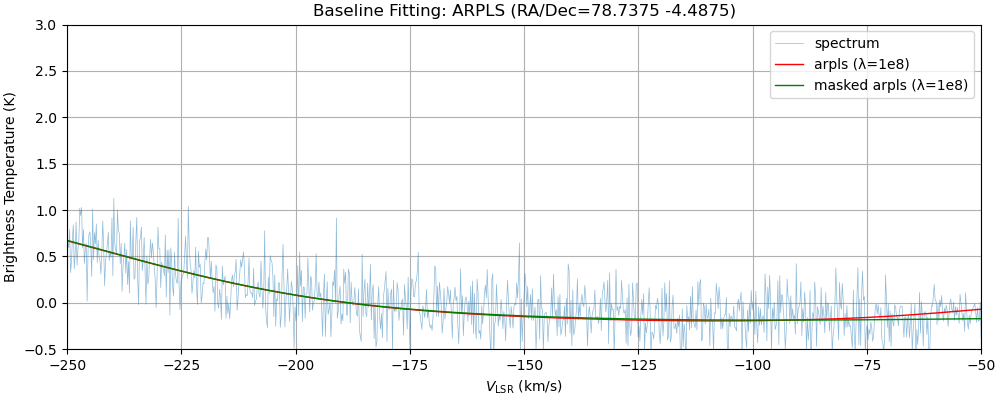

In [5]:
# ARPLS method vs Masked ARPLS method
random_x, random_y = 340, 50
spectrum = data[:, random_y, random_x]
sky = cube.wcs.celestial.pixel_to_world(random_y, random_x)
print(sky)

bkg, params = Baseline(velocities).arpls(spectrum, lam=1e8)
bkg_masked = masked_arpls(spectrum, mask=vel_mask, lam=1e8)

fig = plt.figure(figsize=(10, 4), layout="constrained")
plt.plot(velocities, spectrum, label='spectrum', lw=0.5, alpha=0.5)
plt.plot(velocities, bkg, label='arpls (λ=1e8)', lw=1, color='red')
plt.plot(velocities, bkg_masked, label='masked arpls (λ=1e8)', lw=1, color='green')
plt.legend()
plt.xlabel(r'$V_{\mathrm{LSR}}\ \mathrm{(km/s)}$')
plt.xlim(-250, -50)
plt.ylabel('Brightness Temperature (K)')
plt.ylim(-0.5, 3)
plt.title(f'Baseline Fitting: ARPLS (RA/Dec={sky.to_string('decimal')})')
plt.grid()
plt.show()

Text(0.5, 0.98, 'Baseline Fitting: ARPLS (RA/Dec=78.7375 -4.4875)')

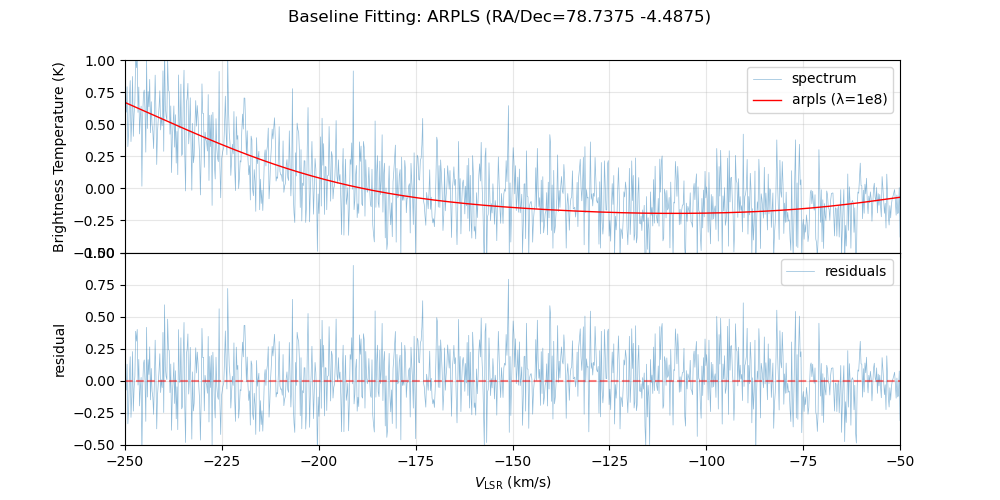

In [6]:
# Residuals
residuals = spectrum - bkg

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 5), sharex=True, gridspec_kw={'hspace': 0})

ax1.plot(velocities, spectrum, label='spectrum', lw=0.5, alpha=0.5)
ax1.plot(velocities, bkg, label='arpls (λ=1e8)', lw=1, color='red')
ax1.set_ylim(-0.5, 1)
ax1.set_ylabel('Brightness Temperature (K)')
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)
ax1.tick_params(labelbottom=False)

ax2.plot(velocities, residuals, label='residuals', lw=0.5, alpha=0.5)
ax2.axhline(y=0, color='r', linestyle='--', alpha=0.5)
ax2.set_xlim(-250, -50)
ax2.set_xlabel(r'$V_{\mathrm{LSR}}\ \mathrm{(km/s)}$')
ax2.set_ylim(-0.5, 1)
ax2.set_ylabel('residual')
ax2.legend(loc='upper right')
ax2.grid(True, alpha=0.3)

plt.suptitle(f'Baseline Fitting: ARPLS (RA/Dec={sky.to_string('decimal')})')

Text(0.5, 0.98, 'Baseline Fitting: ARPLS (RA/Dec=78.7375 -4.4875)')

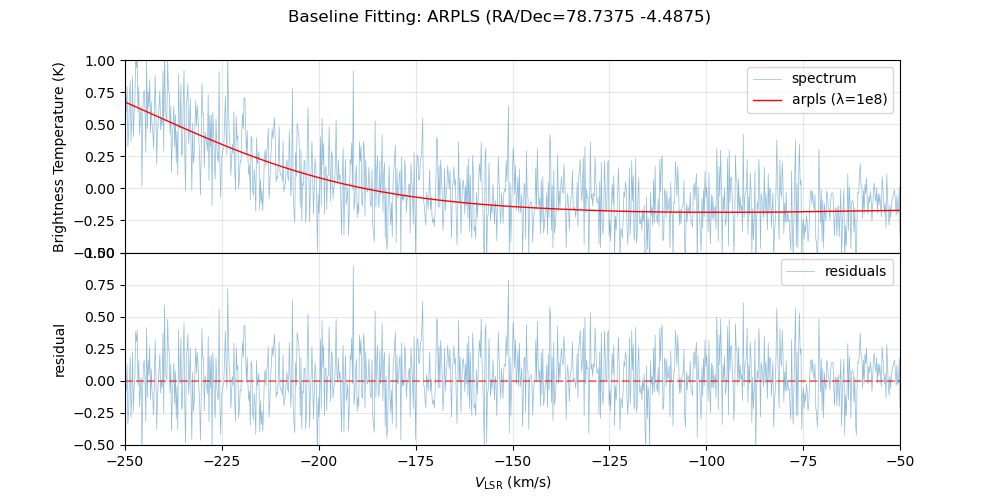

In [7]:
# Residuals (masked)
residuals_masked = spectrum - bkg_masked

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 5), sharex=True, gridspec_kw={'hspace': 0})

ax1.plot(velocities, spectrum, label='spectrum', lw=0.5, alpha=0.5)
ax1.plot(velocities, bkg_masked, label='arpls (λ=1e8)', lw=1, color='red')
ax1.set_ylim(-0.5, 1)
ax1.set_ylabel('Brightness Temperature (K)')
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)
ax1.tick_params(labelbottom=False)

ax2.plot(velocities, residuals_masked, label='residuals', lw=0.5, alpha=0.5)
ax2.axhline(y=0, color='r', linestyle='--', alpha=0.5)
ax2.set_xlim(-250, -50)
ax2.set_xlabel(r'$V_{\mathrm{LSR}}\ \mathrm{(km/s)}$')
ax2.set_ylim(-0.5, 1)
ax2.set_ylabel('residual')
ax2.legend(loc='upper right')
ax2.grid(True, alpha=0.3)

plt.suptitle(f'Baseline Fitting: ARPLS (RA/Dec={sky.to_string('decimal')})')

In [8]:
# 拉平成行谱
dataset = data.transpose(1, 2, 0).reshape(n_y * n_x, n_v)  # shape (480000, 5962)
baselines = np.empty_like(dataset)  # shape (480000, 5962)

# 并行计算
results = Parallel(n_jobs=-1, backend="loky", return_as="generator", verbose=5)(
    delayed(masked_arpls)(dataset[i], vel_mask) for i in range(len(dataset))
)

for i, baseline in enumerate(results):
    baselines[i] = baseline

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 24 concurrent workers.


[Parallel(n_jobs=-1)]: Done  24 tasks      | elapsed:    0.5s
[Parallel(n_jobs=-1)]: Done 114 tasks      | elapsed:    0.6s
[Parallel(n_jobs=-1)]: Done 600 tasks      | elapsed:    0.7s
[Parallel(n_jobs=-1)]: Done 5784 tasks      | elapsed:    1.4s
[Parallel(n_jobs=-1)]: Done 30744 tasks      | elapsed:    3.9s
[Parallel(n_jobs=-1)]: Done 60696 tasks      | elapsed:    6.7s
[Parallel(n_jobs=-1)]: Done 95256 tasks      | elapsed:    9.7s
[Parallel(n_jobs=-1)]: Done 134424 tasks      | elapsed:   13.3s
[Parallel(n_jobs=-1)]: Done 178200 tasks      | elapsed:   17.3s
[Parallel(n_jobs=-1)]: Done 226584 tasks      | elapsed:   21.8s
[Parallel(n_jobs=-1)]: Done 279576 tasks      | elapsed:   26.2s
[Parallel(n_jobs=-1)]: Done 337176 tasks      | elapsed:   31.8s
[Parallel(n_jobs=-1)]: Done 399384 tasks      | elapsed:   37.5s
/tmp/ipykernel_178132/1331976993.py:24: ParameterWarning: almost all baseline points are below the data, indicating that "tol" is too low and/or "max_iter" is too high
/

In [9]:
baselines = baselines.T.reshape(n_v, n_y, n_x)
baselines_cube = sc(data=baselines * u.K, wcs=cube.wcs)
baselines_cube

corrected = data - baselines
corrected *= u.K
corrected_cube = sc(data=corrected, wcs=cube.wcs)
corrected_cube

SpectralCube with shape=(5962, 600, 800) and unit=K:
 n_x:    800  type_x: RA---CAR  unit_x: deg    range:    60.012500 deg:   79.987500 deg
 n_y:    600  type_y: DEC--CAR  unit_y: deg    range:   -12.987500 deg:    1.987500 deg
 n_s:   5962  type_s: VRAD      unit_s: m / s  range:  -599897.172 m / s:  599954.336 m / s

In [10]:
cube_minus = cube.spectral_slab(vel_mask_minus[ra_i,0] * u.km / u.s, vel_mask_minus[ra_i,1] * u.km / u.s)
corrected_cube_minus = corrected_cube.spectral_slab(vel_mask_minus[ra_i, 0] * u.km / u.s, vel_mask_minus[ra_i, 1] * u.km / u.s)
baselines_cube_minus = baselines_cube.spectral_slab(vel_mask_minus[ra_i, 0] * u.km / u.s, vel_mask_minus[ra_i, 1] * u.km / u.s)

cube_plus = cube.spectral_slab(vel_mask_plus[ra_i, 0] * u.km / u.s, vel_mask_plus[ra_i, 1] * u.km / u.s)
corrected_cube_plus = corrected_cube.spectral_slab(vel_mask_plus[ra_i, 0] * u.km / u.s, vel_mask_plus[ra_i, 1] * u.km / u.s)
baselines_cube_plus = baselines_cube.spectral_slab(vel_mask_plus[ra_i, 0] * u.km / u.s, vel_mask_plus[ra_i, 1] * u.km / u.s)

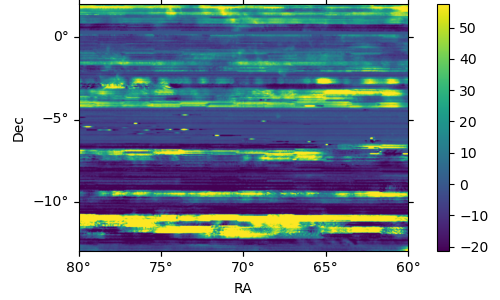

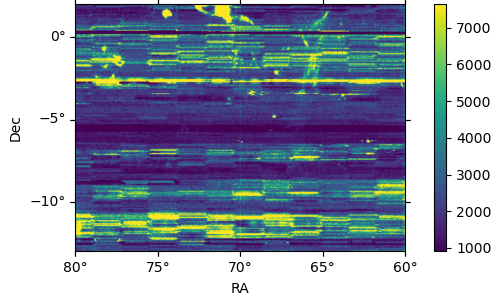

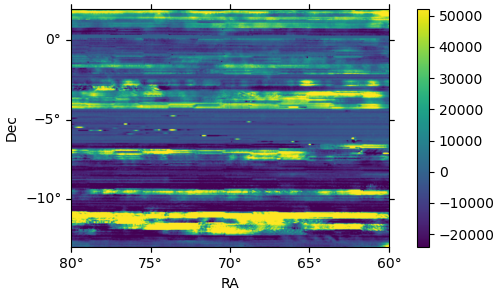

In [12]:
def displayimage(cube, region=None):
    img = cube.moment(order=0).value  # moment 0
    fig, ax = plt.subplots(
        figsize=(5, 3),
        layout="compressed",
        subplot_kw={"projection": cube.wcs.celestial},
    )
    norm = simple_norm(np.array(img), min_percent=5, max_percent=95, stretch="linear")
    im = ax.imshow(img, norm=norm, cmap="viridis", origin="lower")
    lon = ax.coords[0]
    lat = ax.coords[1]
    lon.set_major_formatter("dd")
    lat.set_major_formatter("dd")
    lon.set_axislabel("RA")
    lat.set_axislabel("Dec")
    if region != None:
        region.plot(color="white")
    plt.colorbar(im)
    plt.show()


# Display the corrected cube
displayimage(cube_minus)
displayimage(corrected_cube_minus)
displayimage(baselines_cube_minus)

In [11]:
# Save the corrected cube to a new FITS file
corrected_cube_minus.write(corrected_file_minus, overwrite=True)
corrected_cube_plus.write(corrected_file_plus, overwrite=True)